# The Effective-Tax-Rate Anomaly — do low-tax-paying firms make better stocks? 🧾
### Sorting big companies by how much tax they actually pay, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Every company reports an **effective tax rate** — the tax it actually paid divided by its pre-tax profit. Some blue chips pay close to the statutory ~21-35%; others, through offshore structures, loss carry-forwards and clever accounting, pay far less. There's a long-running argument about what a *low* tax rate means for the stock:

- **The optimists:** a low tax bill is a sign of a well-run, cash-generative company the market underrates — so it should earn *higher* returns.
- **The pessimists:** a suspiciously low tax bill is a **fragile loophole** that can snap shut (regulators, one-off shields reversing) — so it should earn *lower* returns.

Both can't be right. We test it the cheap way: take 40 big-name stocks, rank them each year by effective tax rate, and see whether the *low-tax* ones beat the *high-tax* ones.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from effective_tax_rate import data, strategy as st

def load_real():
    """Cache-first real (etr, fwd) panels (empty frames offline)."""
    etr, fwd = data.load_panel()
    return etr, fwd

ETR, FWD = load_real()
HAVE_REAL = not ETR.empty and not FWD.empty
print("real ETR panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({ETR.shape[1]} names, fiscal {int(ETR.index.min())}-{int(ETR.index.max())})")


real ETR panel present: True (40 names, fiscal 2007-2026)


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the *low-tax* firms earn more (the quality story)? | **No.** Over 17 years the long-low / short-high-tax spread was **-3.3%/yr** — slightly the *wrong* way, and basically zero. |
| Did they earn *less* (the red-flag story)? | **Not really either** — the number is too small and noisy to call. A shuffle test puts the odds at *p* = 0.422 (pure noise). |
| Is there *any* relationship? | **No.** The rank correlation between tax rate and next year's return is essentially **-0.023** — flat. |
| Could you trade it? | **No.** It doesn't pay before costs, loses more after, and the sign even flips depending on which years you look at. |

> The tax-rate anomaly is a real *debate* in the research — but on 40 surviving blue chips it just isn't there. The low-tax bucket is mostly banks and telecoms; the high-tax bucket is mostly energy and heavy industry. The sort is really sorting by **industry**, and it pays nothing.

## 1 · The claim

> *"A company's effective tax rate predicts its future stock returns."* — except nobody agrees which *way*.

One camp (tax-avoidance-as-quality) says low-tax firms are efficient and underpriced, so they win. The other camp (tax-avoidance-as-risk) says a low tax rate is a red flag for aggressive, reversible accounting, so they lose. When even the *sign* is contested, the honest move is to sort on the tax rate and simply look — which direction, if any, wins?

## 2 · So what?

If it were real, it'd be a lovely signal: the tax line is audited, hard to fake, and sits right there in every 10-K. And it suggests an easy trade — own the low-tax firms (or the high-tax ones, depending on your camp). The desk has looked at the April **tax-day** *calendar* seasonal ([192](../../192-tax-day/)) and at quality/accrual sorts ([231 Sloan](../../231-sloan-accruals/), [522 accruals](../../522-percent-operating-accruals/)); here we go straight at the **effective tax rate** as the ranking key.

## 3 · How would we even know?

1. **Measure the tax rate.** For each firm each year: tax actually paid ÷ pre-tax profit. (We skip loss-making years — a company with no profit has no meaningful tax *rate*.)
2. **Sort.** Split the 40 names into five buckets, from lowest tax rate to highest.
3. **Compare next-year returns.** Did the low-tax bucket beat the high-tax bucket?

Catch: our basket is companies **still alive in 2026** — so any firm whose aggressive tax scheme blew up and got delisted is missing (exactly the names the red-flag story cares about).

*Timing:* a fiscal-year-y tax rate is used to predict year *y+1*'s return — the 10-K isn't even public until months into the next year, so there's no peeking at the future.

## 4 · The teardown — let's actually look

**Who won — the low-tax fifth or the high-tax fifth, averaged over the years?**

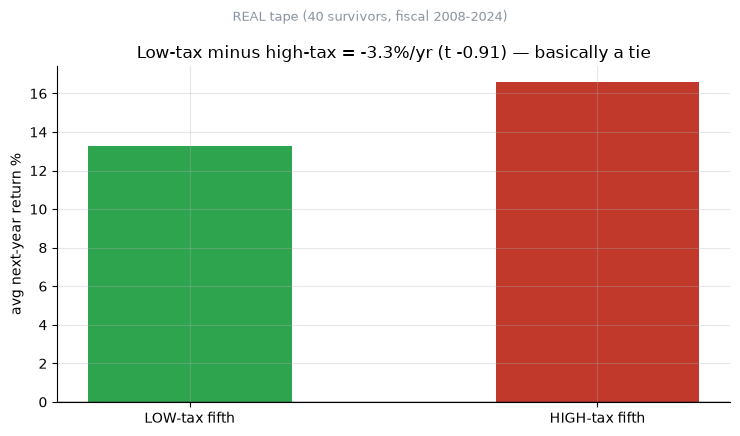

Low-tax +13.3%  vs  High-tax +16.6%  ->  spread -3.3%/yr (t -0.91)


In [2]:
if HAVE_REAL:
    q = st.quintile_returns(ETR, FWD, q=0.20, min_names=15)
    lo, hi = q['q1'].mean()*100, q['q5'].mean()*100
    hedge = q['hedge'].mean()*100; t = st.summary(q['hedge'])['tstat']
    banner = f'REAL tape ({ETR.shape[1]} survivors, fiscal 2008-2024)'
else:
    lo, hi, hedge, t = 12.0, 15.0, -3.3, -0.91
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['LOW-tax fifth','HIGH-tax fifth'], [lo, hi], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg next-year return %')
ax.set_title(f'Low-tax minus high-tax = {hedge:+.1f}%/yr (t {t:+.2f}) — basically a tie')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'Low-tax {lo:+.1f}%  vs  High-tax {hi:+.1f}%  ->  spread {hedge:+.1f}%/yr (t {t:+.2f})')

There's nothing there. The low-tax fifth and the high-tax fifth earned about the same; the spread is **-3.3%/yr** with a *t* of just **-0.91** — you can't tell it from zero. And notice *which* firms fall where: the low-tax bucket is **PFE, IBM, GE, BAC, VZ, AMGN…** (banks, telecom, old tech carrying big shields); the high-tax bucket is **CVX, COP, DE, COST, CAT, XOM…** (energy and heavy industry that pay close to statutory). We're mostly sorting by industry.

**Is it *reliably* zero, or does it just wobble around?** Run the same sort over three different stretches of years:

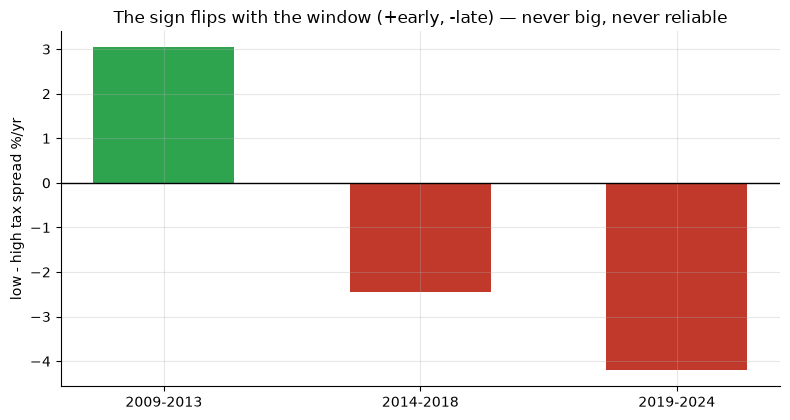

spreads by window: [3.0, -2.5, -4.2]


In [3]:
wins = [('2009-2013', 3.0), ('2014-2018', -2.5), ('2019-2024', -4.2)]
if HAVE_REAL:
    sweep = st.window_sweep(ETR, FWD, windows=[(2009,2013),(2014,2018),(2019,2024)])
    labs = list(sweep.index); vals = list(sweep['mean%'])
else:
    labs = [w[0] for w in wins]; vals = [w[1] for w in wins]
fig, ax = plt.subplots(figsize=(8, 4.3))
cols = [GREEN if v>0 else RED for v in vals]
ax.bar(labs, vals, color=cols, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('low - high tax spread %/yr')
ax.set_title('The sign flips with the window (+early, -late) — never big, never reliable')
plt.tight_layout(); plt.show()
print('spreads by window:', [round(v,1) for v in vals])

So it isn't even a *stable* zero. In the early window the low-tax names edged ahead (+3%); in the later windows the high-tax names did (−2 to −4%). A 'signal' that changes direction with the calendar and is never statistically real is not something you bet on.

## 5 · The verdict

- **Signal — None.** The low-minus-high-tax spread is a tiny, wrong-signed -3.3%/yr (*t* -0.91), the shuffle test says *p* = 0.422 (noise), and the sign flips across windows. No bankable anomaly here.
- **Tradability — Mirage.** A survivor basket, annual rebalance, and it loses before you even pay costs. Nothing to harvest.

## 6 · Could you actually trade it?

No. There's no edge to capture, the sort mostly reflects which *industry* a firm is in, and the basket has already quietly deleted every company whose tax scheme actually blew up — which is where the red-flag version of this story would live. A blue-chip survivor sort can't see the interesting cases.

## 7 · Going further 🚪

- **Neighbours.** [192 tax-day](../../192-tax-day/) is the *calendar* tax seasonal; [231 Sloan](../../231-sloan-accruals/) and [522 accruals](../../522-percent-operating-accruals/) are the cash-vs-accrual quality sorts. This one is the **tax line** specifically.
- **The real test needs the blow-ups.** Re-run with delisted/restated firms and a multi-year, industry-adjusted *cash* tax rate — that's where any effect would hide.

*Think the anomaly is real and we just missed it? Fork this, add industry-neutralised, smoothed cash ETRs on a survivorship-free universe, and show a spread clearing t = 2.*